# Pressure Sensor

In [1]:
!pip install allantools -q

import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats
import allantools
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.titlesize': 12, 'axes.labelsize': 10, 'lines.linewidth': 0.9,
})
CLR = {'raw': '#3498DB', 'trend': '#E74C3C', 'res': '#2C3E50', 'fit': '#E67E22'}


RUN_ID       = "011"
DATA_ROOT    = f"/content/drive/MyDrive/ProjectSHIELD_data/UNIT_0001_RUN_{RUN_ID}"
DATA_PATH    = f"{DATA_ROOT}/pressure.csv"
NOMINAL_HZ   = 50.0


IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            drive.mount('/content/drive')
    except Exception as e:
        print(f"[warn] drive mount skipped: {e}")

print("=" * 64)
print(f"  Pressure Sensor Analysis  —  RUN_{RUN_ID}")
print("=" * 64)
print(f"  DATA_PATH = {DATA_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 4.7 MB/s eta 0:00:00
Mounted at /content/drive
  Pressure Sensor Analysis  —  RUN_011
  DATA_PATH = /content/drive/MyDrive/ProjectSHIELD_data/UNIT_0001_RUN_011/pressure.csv


## 1. Data Loading & Unit Recognition

* **Loading**: Reads the raw pressure.csv file.

* **Unit Detection:** Automatically guesses the  pressure unit (kPa, hPa/mbar, or Pa) based on the median value (e.g., ~101 means kPa, ~101325 means Pa).

* **Standardization:** Converts everything to Pascals (Pa) for scientific calculations and creates a clean time vector in seconds.


In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower() for c in df.columns]

tcol = next((c for c in df.columns if 'time' in c or c == 't' or c == 'ts'), df.columns[0])
vcol = next((c for c in df.columns if c in ('value','pressure','p','pa','kpa','hpa')), df.columns[1])
df = df[[tcol, vcol]].rename(columns={tcol: 't_ms', vcol: 'p_raw'})
df['t_ms']  = pd.to_numeric(df['t_ms'],  errors='coerce')
df['p_raw'] = pd.to_numeric(df['p_raw'], errors='coerce')
df = df.dropna().reset_index(drop=True)

med = df['p_raw'].median()
if   80     <= med <= 110:      unit_in, to_Pa = 'kPa',  1e3
elif 800    <= med <= 1100:     unit_in, to_Pa = 'hPa',  1e2
elif 80000  <= med <= 110000:   unit_in, to_Pa = 'Pa',   1.0
else:                           unit_in, to_Pa = 'kPa',  1e3

df['p_Pa']  = df['p_raw'] * to_Pa
df['p_kPa'] = df['p_Pa'] / 1e3
df['time_s'] = (df['t_ms'] - df['t_ms'].iloc[0]) / 1000.0

duration_s = df['time_s'].iloc[-1]
print(f"rows           : {len(df):,}")
print(f"duration       : {duration_s:.1f} s  ({duration_s/60:.2f} min)")
print(f"raw column     : '{vcol}'  (detected unit = {unit_in})")
print(f"median pressure: {df['p_kPa'].median():.4f} kPa  ({df['p_Pa'].median():.1f} Pa)")
print(f"range          : [{df['p_kPa'].min():.4f}, {df['p_kPa'].max():.4f}] kPa")
df.head()

rows           : 2,698,857
duration       : 54000.0 s  (900.00 min)
raw column     : 'value'  (detected unit = kPa)
median pressure: 101.2850 kPa  (101285.0 Pa)
range          : [101.0348, 101.6205] kPa


,t_ms,p_raw,p_Pa,p_kPa,time_s
0,4829,101.16475,101164.75,101.16475,0.00
1,4849,101.16500,101165.00,101.16500,0.02
2,4869,101.15650,101156.50,101.15650,0.04
3,4889,101.15750,101157.50,101.15750,0.06
4,4909,101.15350,101153.50,101.15350,0.08


## 2.  Timestamp Diagnostics



*  **Sampling Rate: ** Calculates the actual sampling frequency (fs) versus the nominal rate (50 Hz).
*  **Jitter & Gaps:** Analyzes the time differences (dt) between consecutive points to find the median, standard deviation, and identifies if any packets were dropped (gaps > 5x median) or duplicated.
*  **Visualization:** Plots a histogram of the time steps and a time-series of dt to visually inspect for jitter or missing data.



fs (estimated) : 50.000 Hz   (nominal 50.0 Hz, diff 0.00%)
dt median/mean : 20.000 / 20.008 ms
dt std / CV    : 0.953 ms  /  4.76%
dt p99 / max   : 20.00 / 300.00 ms
duplicate (dt=0): 0    backward (dt<0): 0    gaps (>5x med): 79


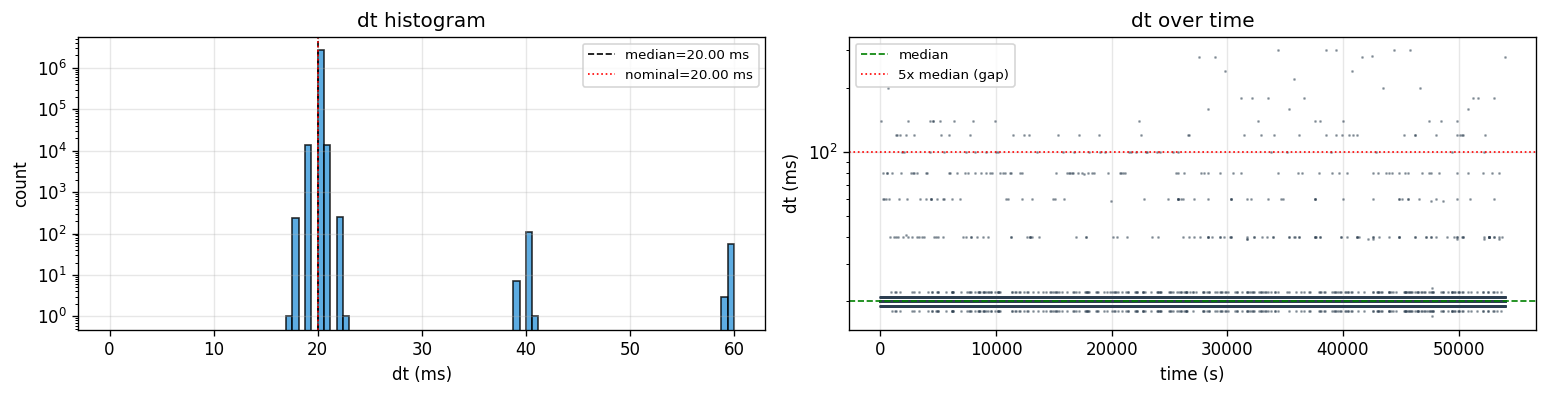

In [3]:
dt = df['t_ms'].diff().dropna().values
dt_pos = dt[dt > 0]
dt_med = float(np.median(dt_pos))
dt_mean = float(dt_pos.mean())
dt_std  = float(dt_pos.std())
dt_p99  = float(np.percentile(dt_pos, 99))
fs_est  = 1000.0 / dt_med
cv      = dt_std / dt_mean if dt_mean else np.nan

gap_th  = 5 * dt_med
n_gaps  = int((dt > gap_th).sum())
n_dup   = int((dt == 0).sum())
n_back  = int((dt < 0).sum())

print(f"fs (estimated) : {fs_est:.3f} Hz   (nominal {NOMINAL_HZ} Hz, "
      f"diff {100*abs(fs_est-NOMINAL_HZ)/NOMINAL_HZ:.2f}%)")
print(f"dt median/mean : {dt_med:.3f} / {dt_mean:.3f} ms")
print(f"dt std / CV    : {dt_std:.3f} ms  /  {cv*100:.2f}%")
print(f"dt p99 / max   : {dt_p99:.2f} / {dt_pos.max():.2f} ms")
print(f"duplicate (dt=0): {n_dup}    backward (dt<0): {n_back}    "
      f"gaps (>5x med): {n_gaps}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
bins = np.linspace(0, max(dt_p99 * 1.5, dt_med * 3), 100)
axes[0].hist(dt_pos, bins=bins, color=CLR['raw'], alpha=0.8, edgecolor='k', lw=0.3)
axes[0].axvline(dt_med, color='k', ls='--', lw=1, label=f'median={dt_med:.2f} ms')
axes[0].axvline(1000.0/NOMINAL_HZ, color='r', ls=':', lw=1,
                label=f'nominal={1000.0/NOMINAL_HZ:.2f} ms')
axes[0].set_yscale('log')
axes[0].set_xlabel('dt (ms)'); axes[0].set_ylabel('count')
axes[0].set_title('dt histogram'); axes[0].legend(fontsize=8)

axes[1].plot(df['time_s'].values[1:], dt, '.', ms=1.5, color='#2C3E50', alpha=0.4, rasterized=True)
axes[1].axhline(dt_med, color='g', ls='--', lw=1, label='median')
axes[1].axhline(gap_th, color='r', ls=':', lw=1, label='5x median (gap)')
axes[1].set_yscale('log')
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('dt (ms)')
axes[1].set_title('dt over time'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


FS = fs_est

## 3. Basic Statistics

- mean / median / std / peak-to-peak
- Drift & Noise: Calculates the end-to-end drift and fits a linear trend line. By subtracting this trend line, it isolates the "detrended residuals" (which represents the pure sensor noise).

In [4]:
p = df['p_Pa'].values
t = df['time_s'].values

n_edge = max(1, int(0.02 * len(p)))
drift_Pa = p[-n_edge:].mean() - p[:n_edge].mean()

slope, intercept, r, _, _ = stats.linregress(t, p)
trend = slope * t + intercept
res   = p - trend

stats_tbl = {
    'N samples'               : len(p),
    'duration (s)'            : duration_s,
    'mean (kPa)'              : p.mean()/1e3,
    'median (kPa)'            : np.median(p)/1e3,
    'std raw (Pa)'            : p.std(),
    'peak-to-peak (Pa)'       : p.max() - p.min(),
    'min (kPa)'               : p.min()/1e3,
    'max (kPa)'               : p.max()/1e3,
    'end-to-end drift (Pa)'   : drift_Pa,
    'linear slope (Pa/s)'     : slope,
    'linear slope (Pa/min)'   : slope * 60,
    'R^2 (linear trend)'      : r**2,
    'std detrended (Pa)'      : res.std(),
}
for k, v in stats_tbl.items():
    print(f"  {k:<28s}: {v:12.5f}" if isinstance(v, float) else f"  {k:<28s}: {v}")

  N samples                   : 2698857
  duration (s)                :  53999.98000
  mean (kPa)                  :    101.29489
  median (kPa)                :    101.28500
  std raw (Pa)                :    160.46816
  peak-to-peak (Pa)           :    585.75000
  min (kPa)                   :    101.03475
  max (kPa)                   :    101.62050
  end-to-end drift (Pa)       :    398.02221
  linear slope (Pa/s)         :      0.00989
  linear slope (Pa/min)       :      0.59357
  R^2 (linear trend)          :      0.92351
  std detrended (Pa)          :     44.38039


## 4. Time-Series Plotting



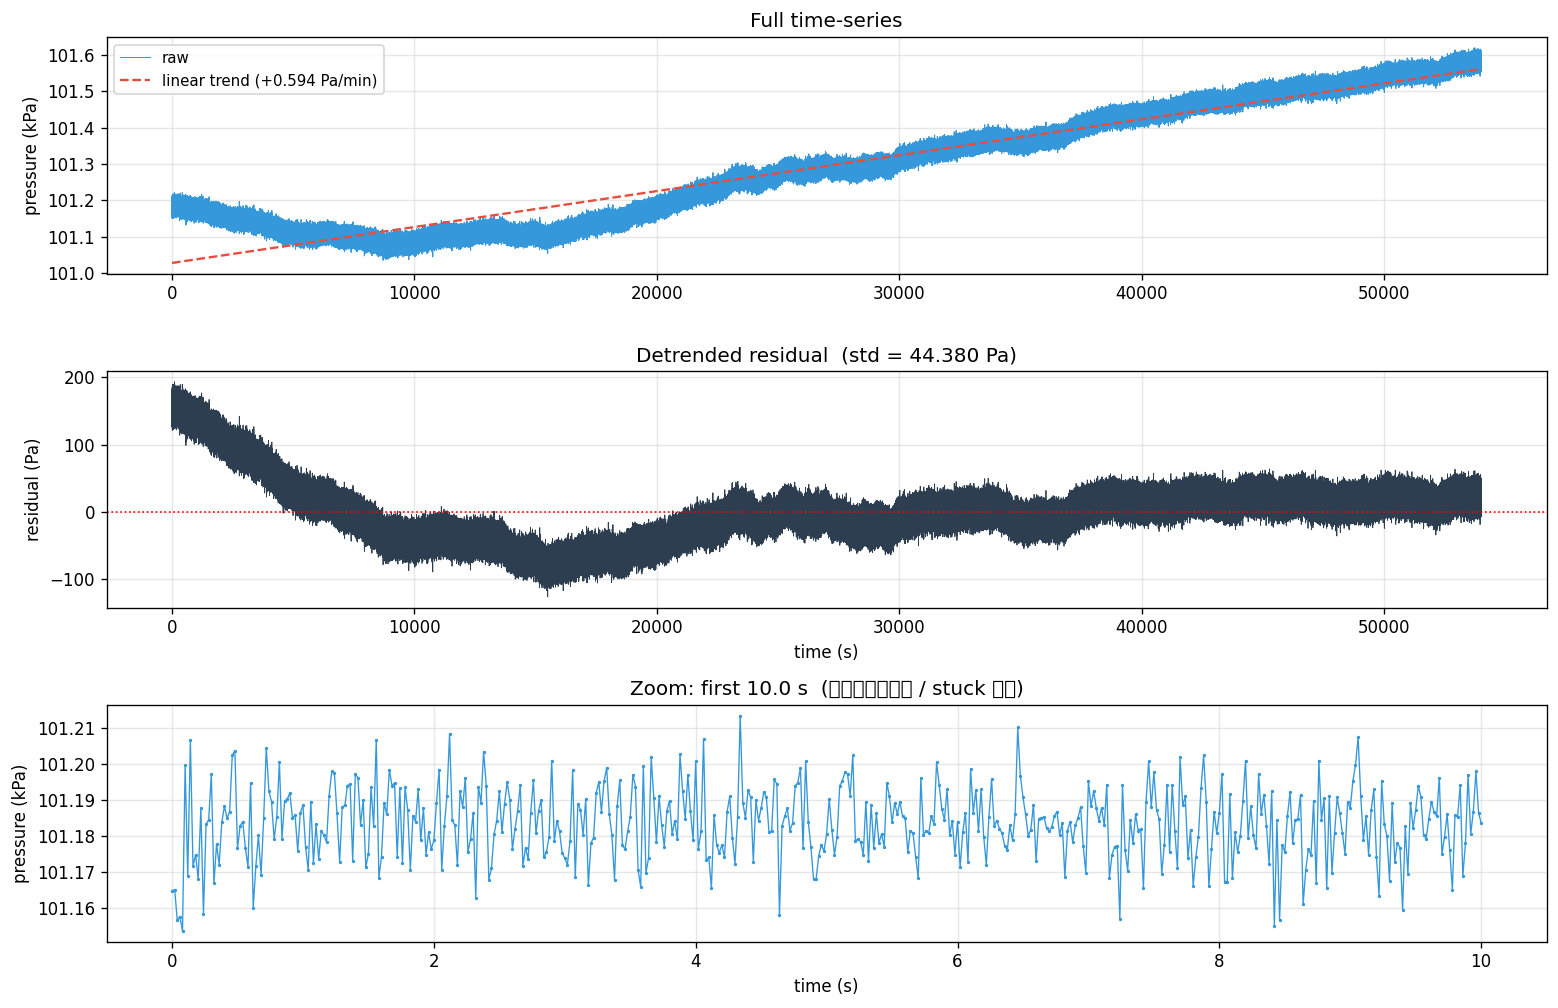

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8.5), sharex=False)

axes[0].plot(t, p/1e3, color=CLR['raw'], lw=0.6, label='raw')
axes[0].plot(t, trend/1e3, color=CLR['trend'], lw=1.4, ls='--',
             label=f'linear trend ({slope*60:+.3f} Pa/min)')
axes[0].set_ylabel('pressure (kPa)')
axes[0].set_title('Full time-series')
axes[0].legend(loc='best', fontsize=9)

axes[1].plot(t, res, color=CLR['res'], lw=0.5)
axes[1].axhline(0, color='r', ls=':', lw=1)
axes[1].set_ylabel('residual (Pa)')
axes[1].set_xlabel('time (s)')
axes[1].set_title(f'Detrended residual  (std = {res.std():.3f} Pa)')

zoom_s = min(10.0, duration_s * 0.1)
mask = t <= zoom_s
axes[2].plot(t[mask], p[mask]/1e3, color=CLR['raw'], lw=0.8, marker='.', ms=2)
axes[2].set_ylabel('pressure (kPa)')
axes[2].set_xlabel('time (s)')
axes[2].set_title(f'Zoom: first {zoom_s:.1f} s  (看单样本量化步 / stuck 样本)')

plt.tight_layout(); plt.show()

## 5. Noise Distribution & Normal Fit



*   If the noise is a perfect Gaussian (Normal) distribution (bell curve), can easily clean the signal using simple moving averages or standard Kalman filters.
*   If it is skewed or has heavy tails (high kurtosis), it means the sensor is experiencing external shocks, vibrations, or digital glitches, and you might need a more complex Median filter or outlier rejection algorithm.


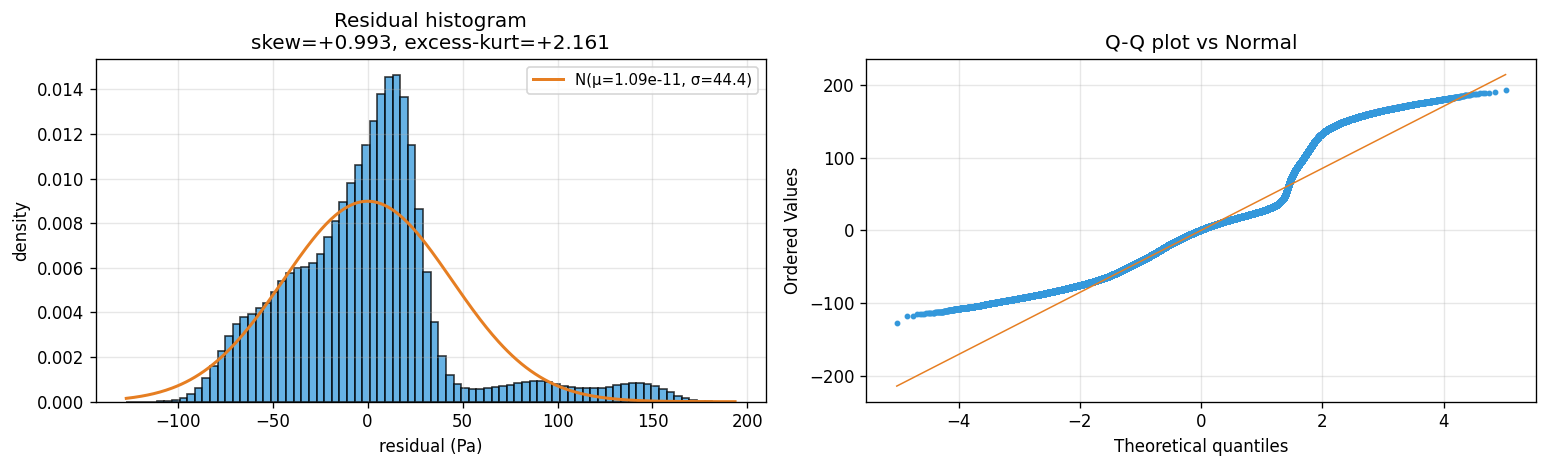

residual mean   = +0.0000 Pa
residual std    = 44.3804 Pa
skewness        = +0.993
excess kurtosis = +2.161   (0 = perfectly Gaussian)


In [6]:
mu, sd = res.mean(), res.std()
skew   = stats.skew(res)
kurt   = stats.kurtosis(res)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
cnt, bins, _ = ax.hist(res, bins=80, density=True, color=CLR['raw'], alpha=0.75, edgecolor='k', lw=0.3)
xs = np.linspace(bins[0], bins[-1], 400)
ax.plot(xs, stats.norm.pdf(xs, mu, sd), color=CLR['fit'], lw=1.8,
        label=f'N(μ={mu:.3g}, σ={sd:.3g})')
ax.set_xlabel('residual (Pa)'); ax.set_ylabel('density')
ax.set_title(f'Residual histogram\nskew={skew:+.3f}, excess-kurt={kurt:+.3f}')
ax.legend(fontsize=9)

ax = axes[1]
stats.probplot(res, dist='norm', plot=ax)
ax.set_title('Q-Q plot vs Normal')
ax.get_lines()[0].set_markersize(2.5)
ax.get_lines()[0].set_color(CLR['raw'])
ax.get_lines()[1].set_color(CLR['fit'])

plt.tight_layout(); plt.show()

print(f"residual mean   = {mu:+.4f} Pa")
print(f"residual std    = {sd:.4f} Pa")
print(f"skewness        = {skew:+.3f}")
print(f"excess kurtosis = {kurt:+.3f}   (0 = perfectly Gaussian)")

## 6. Frequency Domain — Welch PSD

Observe for:
- White Noise Floor (The flat part at high frequencies)
- 1/f Flicker Noise (The upward slope at low frequencies)
- Interference Spikes

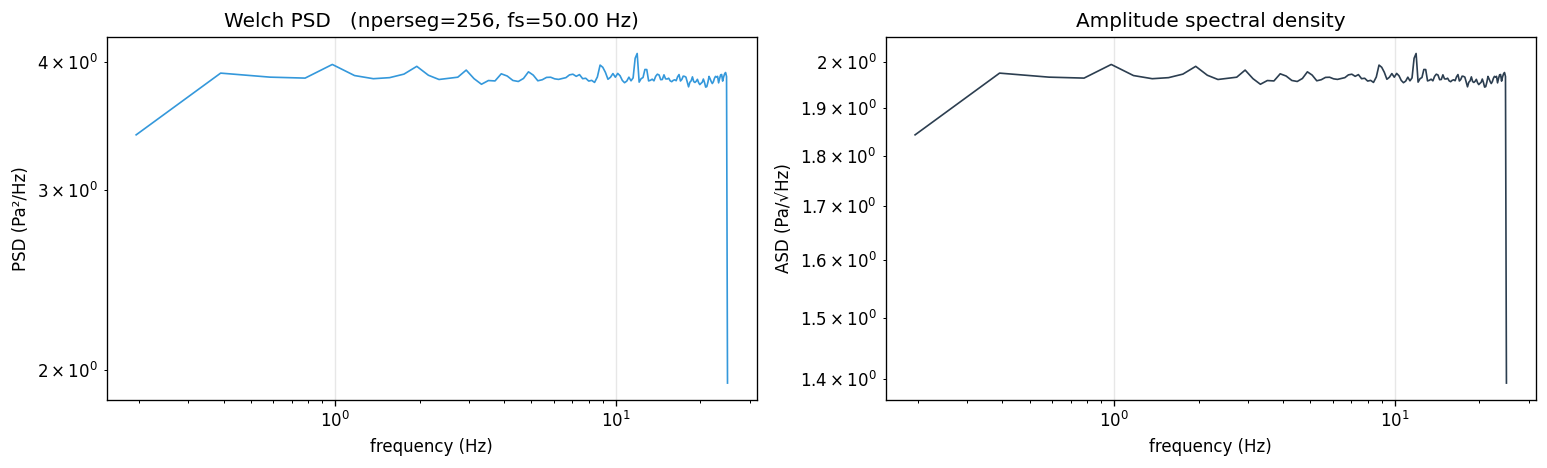

white-noise floor (ASD, 0.25-0.45*fs) ≈ 1.9591 Pa/√Hz


In [7]:
nperseg = int(min(len(res), max(256, 2 ** int(np.log2(FS * 8)))))
f_w, Pxx = signal.welch(res, fs=FS, nperseg=nperseg, detrend='constant')

asd = np.sqrt(Pxx)
mask = f_w > 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].loglog(f_w[mask], Pxx[mask], color=CLR['raw'], lw=1.0)
axes[0].set_xlabel('frequency (Hz)'); axes[0].set_ylabel('PSD (Pa²/Hz)')
axes[0].set_title(f'Welch PSD   (nperseg={nperseg}, fs={FS:.2f} Hz)')

axes[1].loglog(f_w[mask], asd[mask], color=CLR['res'], lw=1.0)
axes[1].set_xlabel('frequency (Hz)'); axes[1].set_ylabel('ASD (Pa/√Hz)')
axes[1].set_title('Amplitude spectral density')

plt.tight_layout(); plt.show()


hf_band = (f_w > FS * 0.25) & (f_w < FS * 0.45)
if hf_band.sum() > 5:
    white_floor = float(np.sqrt(np.median(Pxx[hf_band])))
    print(f"white-noise floor (ASD, 0.25-0.45*fs) ≈ {white_floor:.4f} Pa/√Hz")

In [12]:
from scipy.signal import find_peaks

# f_w and Pxx are already computed from the previous cell
mask = f_w > 0
f_valid = f_w[mask]
pxx_valid = Pxx[mask]

# Use 5x the median PSD as the prominence threshold to ignore normal white noise jitter
median_psd = np.median(pxx_valid)
peaks, properties = find_peaks(pxx_valid, prominence=median_psd * 5)

peak_freqs = f_valid[peaks]
peak_powers = pxx_valid[peaks]

print(f"Nyquist frequency: {FS/2:.1f} Hz. Analyzing for Interference Spikes:\n")

if len(peak_freqs) == 0:
    print(" - No prominent spikes detected. The noise is mostly broadband/white.")
else:
    for f, pwr in zip(peak_freqs, peak_powers):
        source = "Unknown periodic interference / digital crosstalk"

        # Heuristics based on a 50Hz sampling rate
        if f < 2.0:
            source = "Slow environmental changes, thermal drift, or mechanical swaying"
        elif 9.0 <= f <= 11.0:
            source = "Likely aliased 60Hz AC mains power interference (60Hz aliases to 10Hz when sampled at 50Hz)"
        elif 24.0 <= f <= 25.0:
            source = "Likely aliased 50Hz AC mains power interference (aliases to 0Hz/25Hz) or Nyquist noise"

        print(f" - Spike at {f:.2f} Hz | Power: {pwr:.2f} Pa/Hz | Potential Source: {source}")


Nyquist frequency: 25.0 Hz. Analyzing for Interference Spikes:

 - No prominent spikes detected. The noise is mostly broadband/white.


Since sampling rate is 50 Hz, the maximum frequency that can measure without aliasing (the Nyquist frequency) is 25 Hz. This means any interference from standard 60Hz power lines will 'alias' or fold down into the plot at around 10 Hz.

## 7. Allan Variance — Long-Term Stability / Bias Instability

The two most useful parameters for a barometer from this plot are:
- **White Noise (N)**: Short-term random walk coefficient (the slope of −1/2).
- **Bias Instability (B)**: The lowest point on the Allan curve (represents the limit of flicker noise).

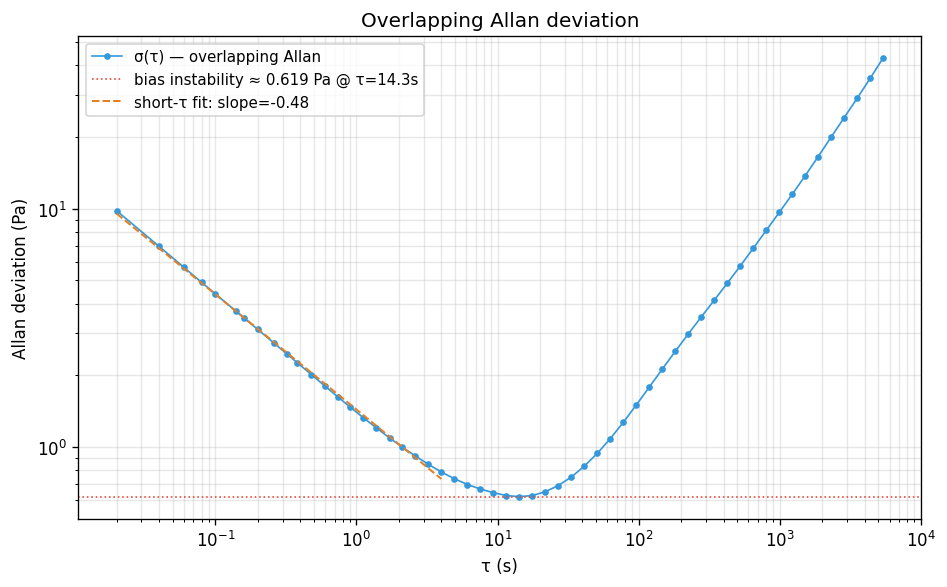

bias instability  : 0.6188 Pa   (τ = 14.28 s)
short-τ log-slope : -0.484  (ideal white noise = -0.5)
white-noise coeff : N ≈ 1.4366 Pa·√s


In [8]:
tau0 = 1.0 / FS
max_tau_pts = len(p) // 10
taus = np.logspace(np.log10(tau0), np.log10(max(tau0*2, max_tau_pts * tau0)), 60)

taus_out, adev, _, _ = allantools.oadev(p, rate=FS, data_type='freq', taus=taus)

imin = int(np.argmin(adev))
bias_inst = float(adev[imin])
tau_bi    = float(taus_out[imin])

fit_mask = taus_out < tau_bi / 3
if fit_mask.sum() >= 3:
    lx = np.log10(taus_out[fit_mask]); ly = np.log10(adev[fit_mask])
    slope_log, inter_log = np.polyfit(lx, ly, 1)
    N_white = 10 ** (inter_log + 0.5 * np.log10(1.0))
else:
    slope_log, N_white = np.nan, np.nan

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(taus_out, adev, 'o-', color=CLR['raw'], ms=3, lw=1, label='σ(τ) — overlapping Allan')
ax.axhline(bias_inst, color=CLR['trend'], ls=':', lw=1,
           label=f'bias instability ≈ {bias_inst:.3f} Pa @ τ={tau_bi:.1f}s')
if fit_mask.sum() >= 3:
    xs = taus_out[fit_mask]
    ax.loglog(xs, 10 ** (slope_log * np.log10(xs) + inter_log), '--', color=CLR['fit'], lw=1.2,
              label=f'short-τ fit: slope={slope_log:+.2f}')
ax.set_xlabel('τ (s)'); ax.set_ylabel('Allan deviation (Pa)')
ax.set_title('Overlapping Allan deviation')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"bias instability  : {bias_inst:.4f} Pa   (τ = {tau_bi:.2f} s)")
if not np.isnan(N_white):
    print(f"short-τ log-slope : {slope_log:+.3f}  (ideal white noise = -0.5)")
    print(f"white-noise coeff : N ≈ {N_white:.4f} Pa·√s")

*   White Noise Coefficient (N): The left side of the curve (slope of -1/2) represents white noise. If your application needs fast, short-term altitude changes, this number dictates your short-term precision.
*   Bias Instability (B): This is the "bottom" of the Allan curve. It represents the absolute best precision your sensor can achieve if you average it optimally. If the bias instability is 0.6 Pa at τ=14s, it means the best you can possibly do is a 0.6 Pa resolution by averaging for 14 seconds. Averaging longer than 14 seconds will actually make your measurement less accurate due to slow drift.

## 8. Pressure to Altitude Conversion

Using the standard atmosphere formula:
$$h = \frac{T_0}{L}\left[1 - (P/P_0)^{RL/(gM)}\right]$$

- $P_0 = 101325$ Pa, $T_0 = 288.15$ K, $L = 0.0065$ K/m
- For static data, relative altitude resolution ≈ noise std × 8.43 cm/Pa (near sea level)

Outputs: Altitude time-series + Altitude noise std (= Effective vertical resolution of the pressure sensor).

sensitivity near sea level : 8.324 cm / Pa
altitude mean              : +2.52 m
altitude detrended std     : 369.50 cm
altitude peak-to-peak      : 4875.90 cm


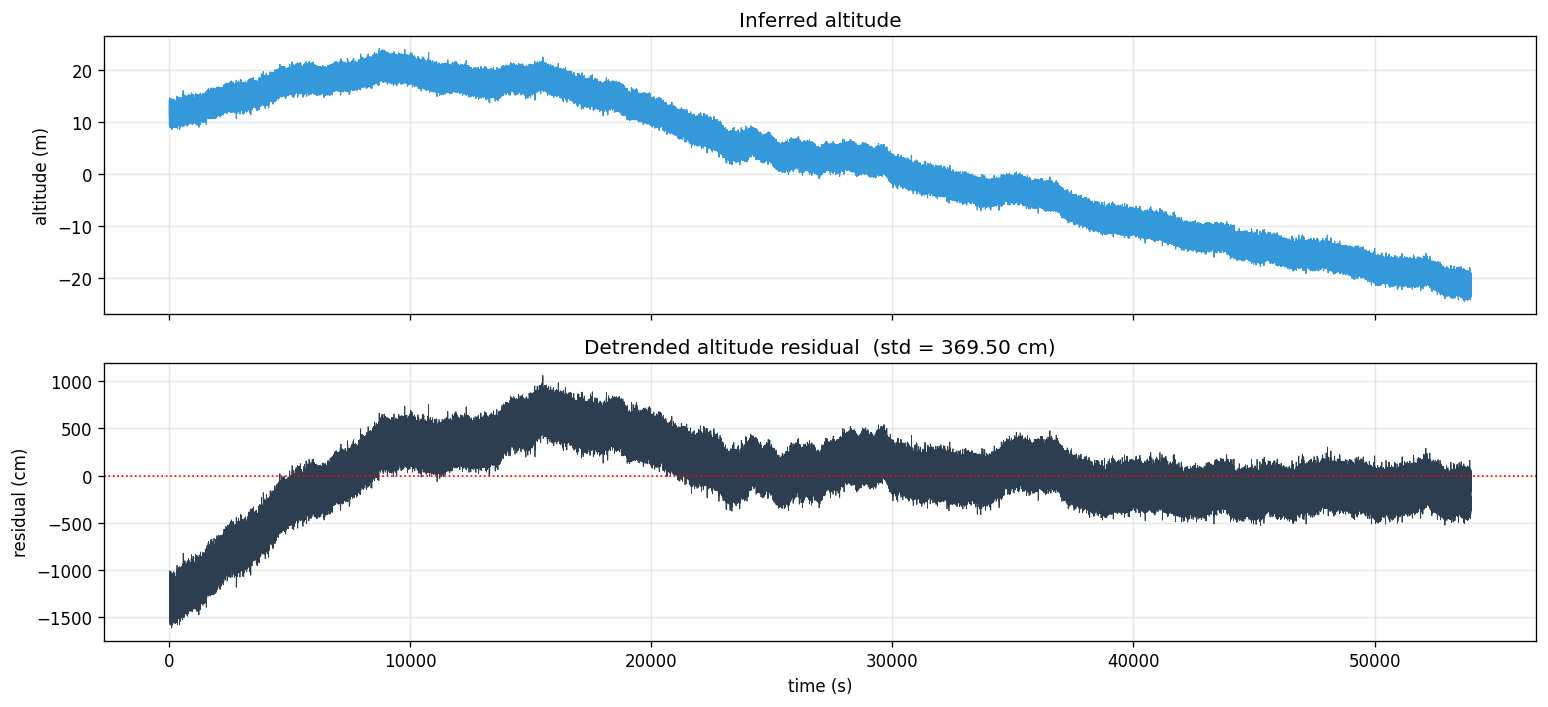

In [9]:
P0 = 101325.0
T0 = 288.15
L  = 0.0065
g  = 9.80665
M  = 0.0289644
R  = 8.31446

def pressure_to_alt(p_Pa, p0=P0):
    return (T0 / L) * (1.0 - (p_Pa / p0) ** (R * L / (g * M)))

alt = pressure_to_alt(p)
alt_res = alt - (slope_a := np.polyval(np.polyfit(t, alt, 1), t))

alt_per_Pa = (pressure_to_alt(P0 - 0.5) - pressure_to_alt(P0 + 0.5))
print(f"sensitivity near sea level : {alt_per_Pa*100:.3f} cm / Pa")
print(f"altitude mean              : {alt.mean():+.2f} m")
print(f"altitude detrended std     : {alt_res.std()*100:.2f} cm")
print(f"altitude peak-to-peak      : {(alt.max()-alt.min())*100:.2f} cm")

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(t, alt, color=CLR['raw'], lw=0.7)
axes[0].set_ylabel('altitude (m)'); axes[0].set_title('Inferred altitude')
axes[1].plot(t, alt_res*100, color=CLR['res'], lw=0.5)
axes[1].axhline(0, color='r', ls=':', lw=1)
axes[1].set_ylabel('residual (cm)'); axes[1].set_xlabel('time (s)')
axes[1].set_title(f'Detrended altitude residual  (std = {alt_res.std()*100:.2f} cm)')
plt.tight_layout(); plt.show()

 *   converts sensor's noise into physical units (centimeters).
 *   The "detrended altitude standard deviation" tells you the effective vertical resolution of your sensor. If this number is, for example, 30 cm, it means the raw sensor data cannot reliably distinguish height changes smaller than a standard stair step without additional filtering or data fusion (like adding an IMU).

## 9. Summary

In [10]:
summary = {
    'run'                       : RUN_ID,
    'N samples'                 : len(p),
    'duration (s)'              : round(duration_s, 2),
    'fs measured (Hz)'          : round(FS, 3),
    'dt CV (%)'                 : round(cv*100, 3),
    'gaps (>5x med)'            : n_gaps,
    'mean (kPa)'                : round(p.mean()/1e3, 5),
    'std raw (Pa)'              : round(p.std(), 4),
    'std detrended (Pa)'        : round(res.std(), 4),
    'peak-to-peak (Pa)'         : round(p.max()-p.min(), 3),
    'linear drift (Pa/min)'     : round(slope*60, 4),
    'bias instability (Pa)'     : round(bias_inst, 4),
    'τ @ bias inst (s)'         : round(tau_bi, 2),
    'altitude std (cm)'         : round(alt_res.std()*100, 2),
    'altitude p2p (cm)'         : round((alt.max()-alt.min())*100, 2),
}

summary_df = pd.DataFrame(summary.items(), columns=['metric', 'value'])
print(summary_df.to_string(index=False))

out_csv = f"pressure_summary_RUN_{RUN_ID}.csv"
summary_df.to_csv(out_csv, index=False)
print(f"\nsaved: {out_csv}")

               metric      value
                  run        011
            N samples    2698857
         duration (s)   53999.98
     fs measured (Hz)       50.0
            dt CV (%)      4.763
       gaps (>5x med)         79
           mean (kPa)  101.29489
         std raw (Pa)   160.4682
   std detrended (Pa)    44.3804
    peak-to-peak (Pa)     585.75
linear drift (Pa/min)     0.5936
bias instability (Pa)     0.6188
    τ @ bias inst (s)      14.28
    altitude std (cm)      369.5
    altitude p2p (cm)     4875.9

saved: pressure_summary_RUN_011.csv
